# Jev: which state layout reads best?

`02_jev_comparison` showed zero-shot Jev getting close to the trees with one way of writing each row down. The wording is a modelling choice, much like the trees' hyperparameters, so this notebook tries four layouts on the same `val` rows and puts all of them next to LightGBM, XGBoost and random forest.

| Layout | Hypothesis |
|---|---|
| `narrative` | Short English sentences, arithmetic done in code (the original from `02`). |
| `numeric` | The same facts as raw numbers with unit-bearing keys: does doing the maths for Jev help? |
| `minimal` | Only age, clock, wake-window progress and the day so far: does less context sharpen it? |
| `qualitative` | No numbers, only judgements relative to her own pattern: plays to Jev's semantics and avoids its maths. |

The layouts live in `baby_ml/layouts.py`, one class each behind a shared `StateLayout` interface.

**A caution on reading this.** Picking the best layout by its `val` score is tuning, just like picking tree hyperparameters on `val`. The winner's `val` number is slightly optimistic. The honest head-to-head is one final run on `test` for the chosen layout and the chosen tree.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import typing

import pandas as pd

from baby_ml import Comparison, JevModel, JevSpec, load_training_set
from baby_ml.jev import example_states
from baby_ml.layouts import LayoutName

LAYOUTS = list(typing.get_args(LayoutName))
df = load_training_set()
print(df.attrs["snapshot"], df.shape)

C:\Users\nikil\dbt-baby-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml_sleep_training_set_20260923T211259.parquet (28713, 63)


## One row, four ways

In [2]:
for layout in LAYOUTS:
    print(f"── {layout}")
    print(json.dumps(example_states(df, n=1, layout=layout)[0], indent=1))

── narrative
{
 "baby": "21 weeks old (5.0 months)",
 "time_now": "13:10 (afternoon)",
 "current_wake_window": "Awake for 1 h 1 min, since waking from a nap that lasted 1 h 26 min. Her typical wake window over the last two weeks is 1 h 57 min, so she is 52% of the way through a typical wake window.",
 "recent_wake_windows": "Her last three wake windows averaged 2 h 14 min.",
 "today_so_far": "Up for the day for 4 h 55 min; 1 nap so far today totalling 1 h 26 min.",
 "last_night": "Slept 10 h 33 min in total, longest stretch 7 h 33 min, woke once.",
 "sleep_last_24h": "14 h 12 min across 4 sleeps, about her usual daily amount.",
 "feeding": "Last feed started 54 min ago (a 12 min breastfeed). 7 feeds in the last 24 hours, about every 3 h 35 min."
}
── numeric
{
 "age_weeks": 21,
 "time_of_day_24h": "13:10",
 "minutes_awake_since_last_sleep": 61,
 "last_sleep_type": "nap",
 "last_sleep_duration_minutes": 86,
 "typical_wake_window_minutes_last_14_days": 117,
 "last_3_wake_windows_average_

## Ask Jev under every layout

Each layout has its own cache in `ml/data/jev/`, so only uncached rows are sent. `narrative` is already cached from `02`.

In [3]:
jev_preds = {}
for layout in LAYOUTS:
    model = JevModel(spec=JevSpec(layout=layout))
    jev_preds[layout] = await model.predict(df, "val")

pd.DataFrame({layout: JevModel(spec=JevSpec(layout=layout)).cost() for layout in LAYOUTS}).T.round(4)

,rows,input_tokens,usd
narrative,4390.0,2927404.0,0.1230
numeric,4390.0,2919404.0,0.1226
minimal,8622.0,4539756.0,0.1907
qualitative,4390.0,2266882.0,0.0952


## All seven models on `val`

In [ ]:
comparison = Comparison.run(df, split="val").with_predictions(
    [pred for preds in jev_preds.values() for pred in preds.values()]
)
metrics = comparison.metrics()
metrics.round(3)

### The headline numbers, ranked

PR-AUC is the headline because positives are the minority. Read it against the base rate (0.222 for 30 minutes, 0.426 for 60). A Brier score below `brier_base_rate` means the probabilities are useful as they stand, not only for ranking.

In [5]:
headline = metrics[["pr_auc", "roc_auc", "brier", "brier_base_rate", "mean_predicted", "base_rate"]]
for label in ["is_asleep_30_mins", "is_asleep_60_mins"]:
    display(headline.loc[label].sort_values("pr_auc", ascending=False).round(3).style.set_caption(label))

,pr_auc,roc_auc,brier,brier_base_rate,mean_predicted,base_rate
model,,,,,,
xgboost,0.582000,0.853000,0.136000,0.173000,0.301000,0.222000
lightgbm,0.567000,0.850000,0.138000,0.173000,0.311000,0.222000
jev_minimal,0.541000,0.821000,0.146000,0.173000,0.340000,0.222000
jev_narrative,0.535000,0.811000,0.148000,0.173000,0.342000,0.222000
random_forest,0.520000,0.838000,0.139000,0.173000,0.310000,0.222000
jev_qualitative,0.470000,0.804000,0.166000,0.173000,0.379000,0.222000
jev_numeric,0.463000,0.739000,0.185000,0.173000,0.395000,0.222000


,pr_auc,roc_auc,brier,brier_base_rate,mean_predicted,base_rate
model,,,,,,
jev_minimal,0.783000,0.849000,0.171000,0.245000,0.483000,0.426000
jev_narrative,0.776000,0.839000,0.180000,0.245000,0.491000,0.426000
lightgbm,0.774000,0.865000,0.162000,0.245000,0.545000,0.426000
xgboost,0.773000,0.865000,0.163000,0.245000,0.548000,0.426000
random_forest,0.761000,0.859000,0.165000,0.245000,0.534000,0.426000
jev_qualitative,0.758000,0.837000,0.189000,0.245000,0.498000,0.426000
jev_numeric,0.683000,0.719000,0.232000,0.245000,0.513000,0.426000


Solid lines are the trees; dashed lines are Jev's layouts.

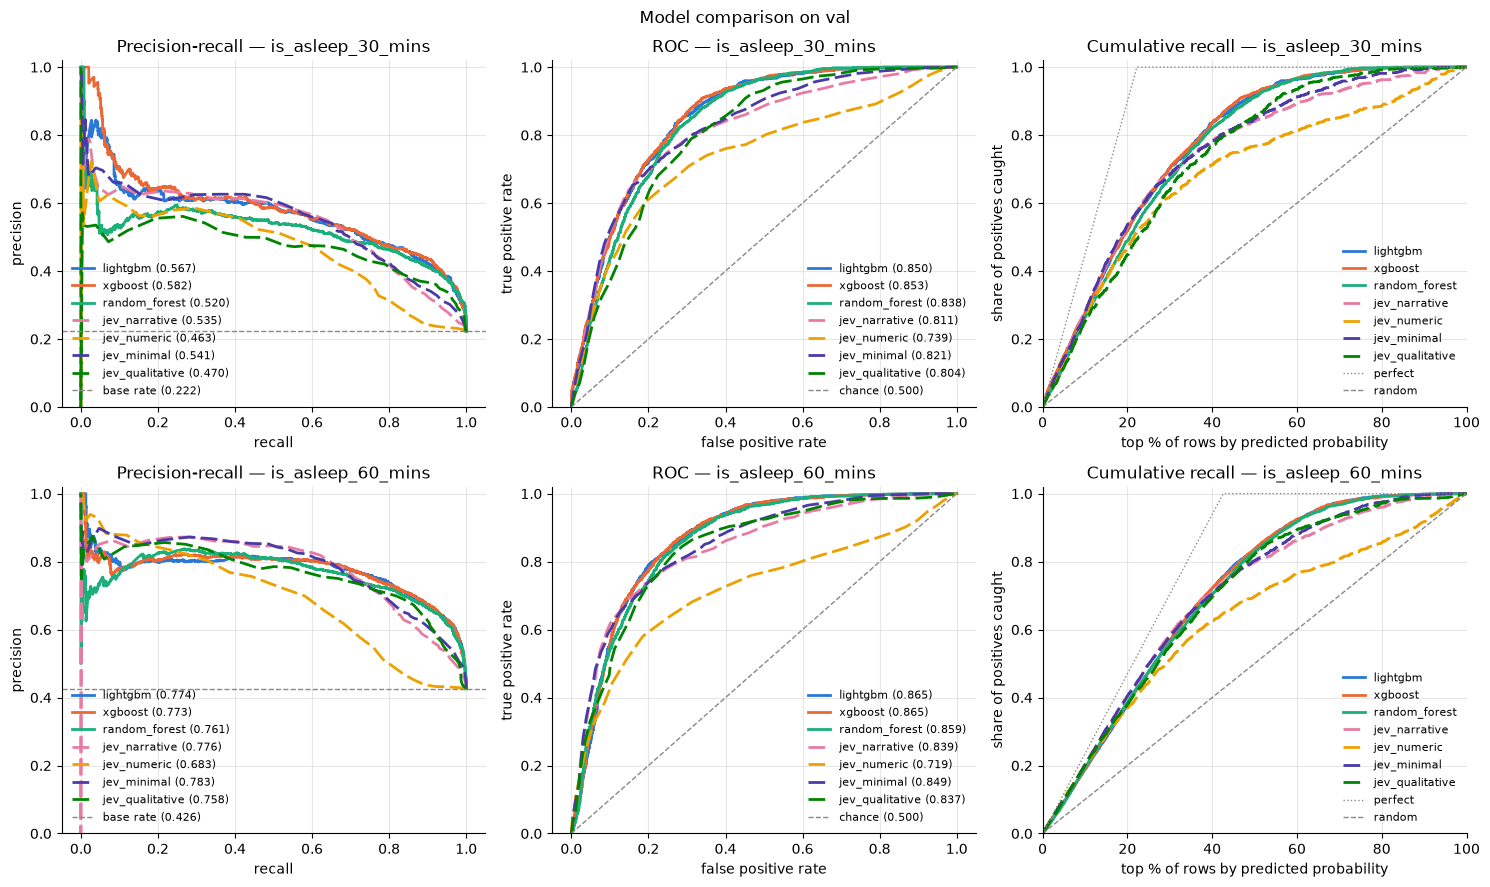

In [6]:
comparison.plot_performance();

In [ ]:
comparison.recall_at_percentiles().round(3)

## What the layouts show

Numbers are from the run above, on `val` (4,390 rows, about 45 days).

**1. How the numbers are written matters far more than which facts are included.** `numeric` gives Jev exactly the same facts as `narrative`, just as raw minutes, and it's by far the worst layout: ROC-AUC 0.739 against 0.811 for 30 minutes. Its Brier score (0.185) is *worse than predicting the base rate* (0.173), so its probabilities are worse than useless as they stand, and they bunch into a narrow 0.26–0.54 band. This matches Jev's docs on numeric reasoning: doing the arithmetic in code is load-bearing.

**2. Less context helped slightly.** `minimal` drops last night, the 24-hour totals and feeding, and scores the same as or a little better than `narrative` on every metric, for 20% fewer tokens. Those facts added noise for Jev, consistent with the docs' "send only what the question needs". The gap (0.006 PR-AUC) is within noise, though, so the fair conclusion is "no worse", not "better".

**3. Pure judgements lose too much.** `qualitative` avoids numbers entirely and lands in between. Rounding "52% through her wake window" down to "past the halfway point" throws away resolution the ranking needs (30-minute PR-AUC 0.470).

**4. Zero-shot Jev against 20,000 training rows.** The best layout, `minimal`, beats the random forest on 30 minutes (PR-AUC 0.541 vs 0.520). On 60 minutes it has the highest PR-AUC of all seven (0.783 vs 0.774 for LightGBM). The trees still win where it counts overall:
- **ROC-AUC:** 0.850–0.865 against 0.821–0.849.
- **Brier score:** 0.136–0.165 against 0.146–0.171.
- **Recall further down the ranking:** in the top 50% of rows, the trees catch 92% of 30-minute sleeps and Jev 85%.
- **Where Jev draws level is the top of the ranking.** The 20% of rows it's most confident about catch as many sleeps as the trees' top 20% (0.537 vs 0.519).

**Caveats**
- There are no confidence intervals yet, and differences of about 0.01 are within day-to-day noise.
- Choosing `minimal` because it won on `val` is tuning, so its `val` score is optimistic. The honest head-to-head is one run of `jev_minimal` and XGBoost on `test`.
- Everyone is over-confident on 30 minutes: the base rate is 0.222, while the trees average about 0.30 and Jev about 0.34. On 60 minutes Jev is actually closer to the base rate (0.48 vs 0.43) than the trees (about 0.545).